# 모델 성능 리포트 — 코드로 다시 계산하기

`docs/HG-모델-성능-리포트.md` 의 모든 수치를 DB 에서 재산출한다. 문서의 숫자를 옮겨 적지 않는다.

| 항목 | 값 |
|---|---|
| 모델 | `v1.0.0` · 7문항 · 다항 로지스틱 회귀 |
| 데이터 | train 2,398 / test 602 (DB 에 고정) |
| 교차검증 | **Stratified 5-Fold** (DB 의 `cv_fold`) |

## 다루는 것

1. 분할이 정말 **층화**인가 — 폴드별 구성으로 확인
2. 교차검증 실행과 폴드별 성적
3. **혼동행렬** — 교차검증 · test
4. 구간별 정밀도·재현율·F1
5. **고부담 여부 2분류** — 이 서비스가 실제로 묻는 것
6. 성공 기준 판정

## 안전

- DB 는 **읽기만** 한다 · `models/` 를 건드리지 않는다
- `ml/train.py` 의 함수를 그대로 불러 쓴다 (계산이 갈라지지 않게)

## 1. 준비

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# sklearn 을 train.py 보다 먼저 올린다 — train.py 가 sys.path 를 바꾸기 때문
import numpy as np, pandas as pd, sklearn, pymysql
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap

def load_env():
    for d in (ROOT, *ROOT.parents):
        p = d / '.env'
        if p.is_file():
            for line in p.read_text(encoding='utf-8').splitlines():
                line = line.strip()
                if line and not line.startswith('#') and '=' in line:
                    k, v = line.split('=', 1)
                    os.environ.setdefault(k.strip(), v.strip().strip('\'"'))
            return p
print('.env :', load_env())
sys.path.insert(0, str(ROOT/'ml'))
import train as T, db as dbmod

_inst = {f.name for f in font_manager.fontManager.ttflist}
for f in ['AppleGothic','Apple SD Gothic Neo','NanumGothic','Malgun Gothic']:
    if f in _inst: mpl.rcParams['font.family'] = f; break
mpl.rcParams['axes.unicode_minus'] = False
SURFACE, INK1, INK2, GRID, AXIS = '#fcfcfb','#0b0b0b','#52514e','#e6e5e1','#c8c7c2'
CAT1, CAT2, CAT3 = '#2a78d6','#eb6834','#8a8a86'
SEQ = ['#f7f6f3','#dfe7f3','#b6c9e6','#7f9fd4','#4a7cc0','#1c5cab']
mpl.rcParams.update({'figure.facecolor':SURFACE,'axes.facecolor':SURFACE,'savefig.facecolor':SURFACE,
                     'figure.dpi':110,'font.size':10,'axes.titlesize':12,'axes.titleweight':'bold',
                     'axes.titlecolor':INK1,'axes.labelcolor':INK2,'text.color':INK1,
                     'xtick.color':INK2,'ytick.color':INK2})
def style(ax, grid='y'):
    ax.set_axisbelow(True)
    if grid: ax.grid(axis=grid, color=GRID, lw=0.8, zorder=0)
    for s in ('top','right'): ax.spines[s].set_visible(False)
    for s in ('left','bottom'): ax.spines[s].set_color(AXIS); ax.spines[s].set_linewidth(0.8)
    ax.tick_params(length=0); return ax
NAME = {1:'최고부담군',2:'고부담군',3:'중간부담군',4:'저부담군',5:'부담없음'}
LV = [1,2,3,4,5]
print('시드', T.SEED, '· sklearn', sklearn.__version__)

.env : /Users/pioneer3/project2608/.env


시드 20260901 · sklearn 1.9.0


## 2. 적재 — 모델과 데이터

In [2]:
d = dbmod.load_dataset(T.MISSING)
model = json.loads((ROOT/'models'/'model_v1.json').read_text(encoding='utf-8'))
qs    = json.loads((ROOT/'models'/'questions_v1.json').read_text(encoding='utf-8'))
SEL, W = model['features'], model['decision_weights']
idx = {f:i for i,f in enumerate(d['features'])}; cols = [idx[f] for f in SEL]
Xtr, y, folds = d['X'][:,cols], d['y'], d['folds']
Xte, yte = d['Xtest'][:,cols], d['ytest']

print(f"모델 {model['model_version']} · {model['family']} · 문항 {len(SEL)}개 · 결정 가중치 {W}")
print(f"train {len(y):,} / test {len(yte):,}\n")
for q in sorted(qs['questions'], key=lambda x: x['questionNo']):
    print(f"  {q['questionNo']}. [{q['originalItem']:>4}] {q['text'][:46]}")

모델 v1.0.0 · logit · 문항 7개 · 결정 가중치 [1.1, 1.1, 1.0, 1.0, 1.0]
train 2,398 / test 602

  1. [  G8] 당사자는 요즘 하루하루의 일과를 어떻게 느끼고 있나요?
  2. [  F5] 당사자의 취업에 대해 가족들이 어느 정도 지지하고 있나요?
  3. [  G6] 돌보고 계신 당사자에게 하루 중 어느 정도의 도움이 필요한가요?
  4. [  I4] 가구의 생계를 주로 책임지는 분은 누구인가요?
  5. [  E4] (일을 그만둔 적이 있다면) 마지막 일자리를 그만둔 가장 큰 이유는 무엇인가요?
  6. [  A1] 응답하시는 분은 당사자와 어떤 관계인가요?
  7. [  F1] 당사자는 "일을 한다"는 것의 의미를 어느 정도 이해하고 있나요?


## 3. 분할이 층화(Stratified)인가

**일반 K-Fold 라면 폴드마다 구간 비율이 들쭉날쭉해야 한다.** 특히 `부담없음` 은
train 2,398건 중 61건(2.5%)뿐이라, 무작위로 나누면 폴드당 8~17건으로 흔들린다.

폴드별 건수


,최고부담군,고부담군,중간부담군,저부담군,부담없음
fold,,,,,
1,75,187,147,61,13
2,74,187,147,61,12
3,74,186,146,60,12
4,74,186,146,60,12
5,74,186,146,60,12


폴드별 구성 비율 (%)


,최고부담군,고부담군,중간부담군,저부담군,부담없음
fold,,,,,
1,15.53,38.72,30.43,12.63,2.69
2,15.38,38.88,30.56,12.68,2.49
3,15.48,38.91,30.54,12.55,2.51
4,15.48,38.91,30.54,12.55,2.51
5,15.48,38.91,30.54,12.55,2.51


,전체 비율 %,폴드 간 최대 편차 %p
최고부담군,15.47,0.15
고부담군,38.87,0.19
중간부담군,30.53,0.13
저부담군,12.59,0.13
부담없음,2.54,0.20


전체 최대 편차 0.20%p → 층화(Stratified) K-Fold 다


findfont: Failed to find font weight bold, now using 400.


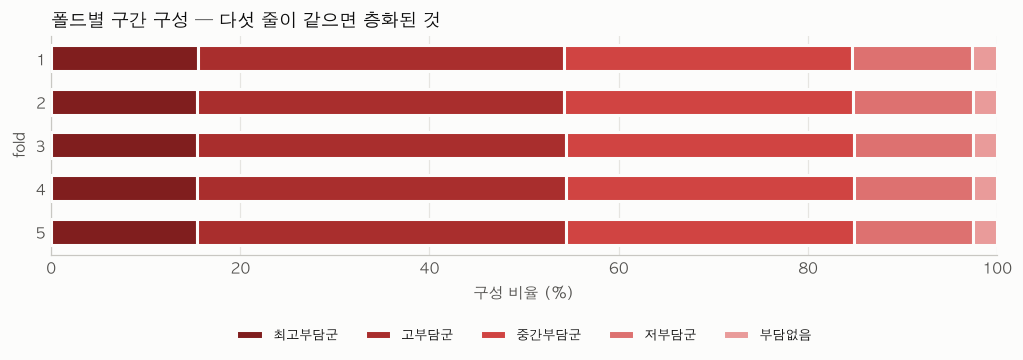

In [3]:
ct = pd.crosstab(pd.Series(folds, name='fold'), pd.Series(y, name='구간'))
ct.columns = [NAME[c_] for c_ in ct.columns]
pct = (ct.div(ct.sum(axis=1), axis=0)*100).round(2)
print('폴드별 건수'); display(ct)
print('폴드별 구성 비율 (%)'); display(pct)

dev = pd.Series({c_: pct[c_].max()-pct[c_].min() for c_ in pct.columns}, name='폴드 간 최대 편차 %p')
overall = pd.Series({NAME[l]: (y==l).mean()*100 for l in LV}, name='전체 비율 %').round(2)
display(pd.concat([overall, dev.round(2)], axis=1))
print(f'전체 최대 편차 {dev.max():.2f}%p → ', end='')
print('층화(Stratified) K-Fold 다' if dev.max() < 1 else '층화가 아닐 수 있다')

fig, ax = plt.subplots(figsize=(9.4, 3.6)); style(ax)
left = np.zeros(5)
ramp = {1:'#801e1e',2:'#a92e2d',3:'#d04442',4:'#dd7170',5:'#e99b9a'}
for i, l in enumerate(LV):
    v = pct[NAME[l]].values
    ax.barh(pct.index.astype(str), v, left=left, height=0.6, color=ramp[l],
            edgecolor=SURFACE, lw=2, zorder=3, label=NAME[l])
    left += v
ax.set_xlim(0,100); ax.set_xlabel('구성 비율 (%)'); ax.set_ylabel('fold')
ax.invert_yaxis(); ax.grid(axis='x', color=GRID, lw=0.8)
ax.set_title('폴드별 구간 구성 — 다섯 줄이 같으면 층화된 것', loc='left')
ax.legend(frameon=False, ncol=5, fontsize=8.6, loc='upper center', bbox_to_anchor=(0.5,-0.28))
fig.tight_layout(); plt.show()

## 4. 교차검증 실행

폴드 하나를 빼고 4개로 학습해 뺀 폴드를 맞히기를 5번 반복한다.
모든 사람이 정확히 한 번씩 **"처음 보는 사람"** 으로 채점된다(out-of-fold).

`ml/train.py` 의 `cv_scores` 를 그대로 쓴다 — 노트북이 별도 구현을 두지 않는다.

In [4]:
r = T.cv_scores(Xtr, y, folds, SEL, family='logit')
pred_cv = T.decide(r['oof_proba'], W)

rows = []
for k in LV:
    m = folds == k
    hb = (y[m] <= 2)
    rows.append({'fold': k, 'n': int(m.sum()),
                 '정확도': (pred_cv[m]==y[m]).mean(),
                 '고부담 재현율': ((pred_cv[m]<=2) & hb).sum()/hb.sum()})
fold_tbl = pd.DataFrame(rows).set_index('fold')
display(fold_tbl.round(4))
print(f"평균 정확도 {fold_tbl['정확도'].mean():.4f} · 폴드 간 편차 "
      f"{fold_tbl['정확도'].max()-fold_tbl['정확도'].min():.4f}")
print(f"CV macro F1 {r['macro_f1']:.4f} · 고부담 재현율 {r['high_burden_recall']:.4f} (가중치 미적용)")

,n,정확도,고부담 재현율
fold,,,
1,483,0.4472,0.7748
2,481,0.4449,0.7701
3,478,0.4874,0.8115
4,478,0.4895,0.8231
5,478,0.4456,0.7423


평균 정확도 0.4629 · 폴드 간 편차 0.0446
CV macro F1 0.3359 · 고부담 재현율 0.7491 (가중치 미적용)


## 5. 혼동행렬

행이 **실제**, 열이 **예측**이다. 대각선이 맞힌 것이고, 대각선에서 멀수록 크게 틀린 것이다.

,예측 최고부담군,예측 고부담군,예측 중간부담군,예측 저부담군,예측 부담없음
실제 최고부담군,68,255,44,4,0
실제 고부담군,55,644,189,44,0
실제 중간부담군,17,337,304,72,2
실제 저부담군,6,84,121,91,0
실제 부담없음,1,7,25,25,3


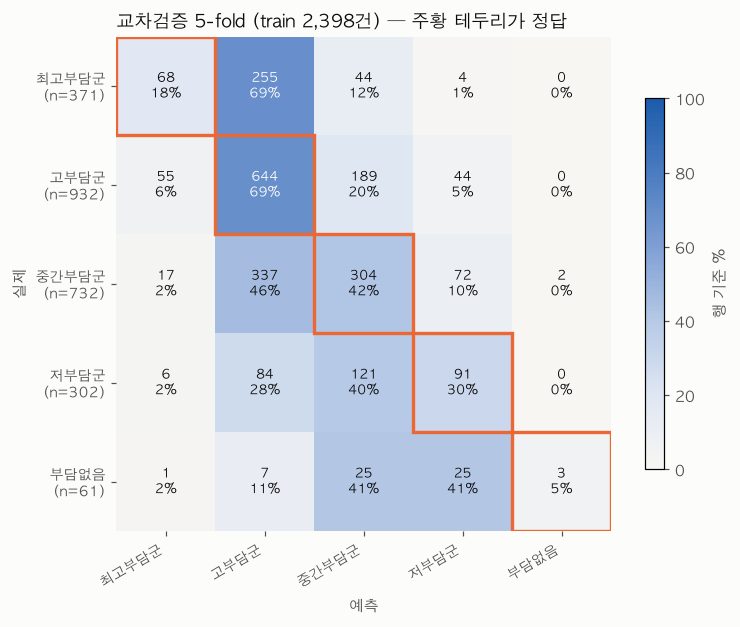

정확도 0.4629
              precision    recall  f1-score   support

       최고부담군      0.463     0.183     0.263       371
        고부담군      0.485     0.691     0.570       932
       중간부담군      0.445     0.415     0.430       732
        저부담군      0.386     0.301     0.338       302
        부담없음      0.600     0.049     0.091        61

    accuracy                          0.463      2398
   macro avg      0.476     0.328     0.338      2398
weighted avg      0.460     0.463     0.438      2398



In [5]:
def draw_cm(yy, pp, title):
    cm = confusion_matrix(yy, pp, labels=LV)
    dfm = pd.DataFrame(cm, index=[f'실제 {NAME[l]}' for l in LV],
                           columns=[f'예측 {NAME[l]}' for l in LV])
    display(dfm)
    row = cm / cm.sum(axis=1, keepdims=True) * 100
    cmap = LinearSegmentedColormap.from_list('seq', SEQ)
    fig, ax = plt.subplots(figsize=(7.4, 5.8))
    im = ax.imshow(row, cmap=cmap, vmin=0, vmax=100)
    ax.set_xticks(range(5)); ax.set_xticklabels([NAME[l] for l in LV], rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(5)); ax.set_yticklabels([f'{NAME[l]}\n(n={cm[i].sum()})' for i,l in enumerate(LV)], fontsize=9)
    for i in range(5):
        for j in range(5):
            ax.annotate(f'{cm[i,j]}\n{row[i,j]:.0f}%', (j,i), ha='center', va='center',
                        fontsize=8.4, color='white' if row[i,j] > 55 else INK1)
    for i in range(5):
        ax.add_patch(plt.Rectangle((i-.5,i-.5),1,1, fill=False, edgecolor=CAT2, lw=2.2))
    ax.set_xlabel('예측'); ax.set_ylabel('실제')
    ax.set_title(title, loc='left')
    fig.colorbar(im, ax=ax, shrink=0.75, label='행 기준 %')
    for s in ax.spines.values(): s.set_visible(False)
    fig.tight_layout(); plt.show()
    print(f'정확도 {(pp==yy).mean():.4f}')
    print(classification_report(yy, pp, labels=LV, target_names=[NAME[l] for l in LV],
                                zero_division=0, digits=3))

draw_cm(y, pred_cv, '교차검증 5-fold (train 2,398건) — 주황 테두리가 정답')

### 읽는 법

- **답이 "고부담군"으로 몰린다** — 결정 가중치 1.1 로 고부담 쪽에 기울여둔 결과다. 의도된 설계이며,
  놓치는 것보다 과하게 잡는 편이 낫다는 판단이다(SC-005)
- **최고부담군을 한 칸 내려 판정하는 경우가 많다** — 다만 최고부담군·고부담군 둘 다 즉시 안내
  대상이라 실질 피해는 작다
- **왼쪽 아래·오른쪽 위 구석이 비어 있는지** 보라. 부담이 큰 사람을 "부담 없음"으로 판정하는
  것이 가장 위험한 실수다

## 6. test 602건 — 최종 평가

,예측 최고부담군,예측 고부담군,예측 중간부담군,예측 저부담군,예측 부담없음
실제 최고부담군,24,62,6,1,0
실제 고부담군,11,155,54,13,0
실제 중간부담군,4,77,89,14,0
실제 저부담군,2,21,32,20,1
실제 부담없음,1,4,7,4,0


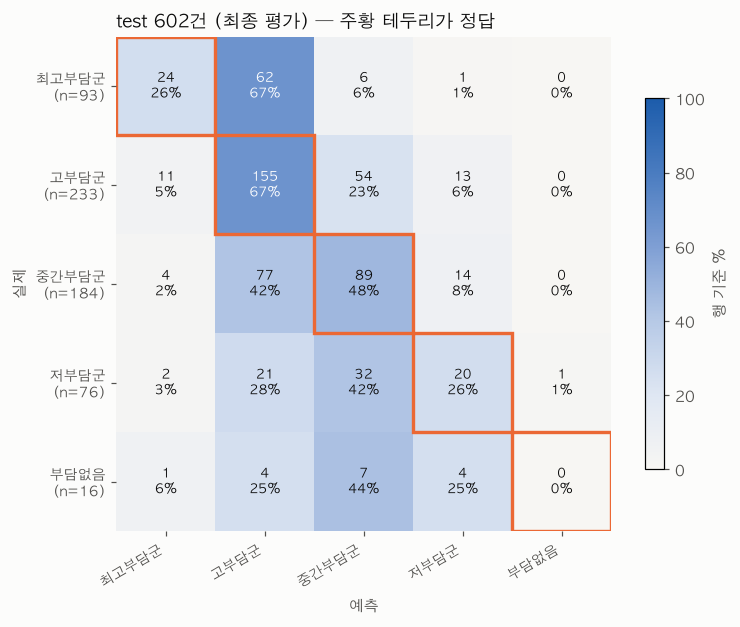

정확도 0.4784
              precision    recall  f1-score   support

       최고부담군      0.571     0.258     0.356        93
        고부담군      0.486     0.665     0.562       233
       중간부담군      0.473     0.484     0.478       184
        저부담군      0.385     0.263     0.312        76
        부담없음      0.000     0.000     0.000        16

    accuracy                          0.478       602
   macro avg      0.383     0.334     0.342       602
weighted avg      0.470     0.478     0.458       602


test 정확도가 교차검증보다 높으면 과적합이 심하지 않다는 뜻이다.


In [6]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
A = enc.fit_transform(Xtr); B = enc.transform(Xte)
lr = LogisticRegression(max_iter=2000, random_state=T.SEED).fit(A, y)
pred_te = T.decide(lr.predict_proba(B), W)
draw_cm(yte, pred_te, 'test 602건 (최종 평가) — 주황 테두리가 정답')
print('\ntest 정확도가 교차검증보다 높으면 과적합이 심하지 않다는 뜻이다.')

## 7. 실제로 중요한 지표 — 고부담 여부 2분류

이 서비스가 물어야 할 것은 "몇 단계인가"가 아니라 **"지원이 필요한 사람인가"** 다.
1~2단계를 하나로 묶으면 그림이 달라진다.

══ 교차검증 ══


,예측 고부담,예측 아님
실제 고부담,1022,281
실제 아님,452,643


  재현율 0.7843 · 정밀도 0.6934 · 정확도 0.6943
  → 실제 고부담 10명 중 7.8명을 잡아내고, 고부담이라 안내한 10명 중 6.9명이 실제 고부담

══ test ══


,예측 고부담,예측 아님
실제 고부담,252,74
실제 아님,109,167


  재현율 0.7730 · 정밀도 0.6981 · 정확도 0.6960
  → 실제 고부담 10명 중 7.7명을 잡아내고, 고부담이라 안내한 10명 중 7.0명이 실제 고부담


,재현율,정밀도,정확도,5구간 정확도
구분,,,,
교차검증,0.7843,0.6934,0.6943,0.4629
test,0.7730,0.6981,0.6960,0.4784


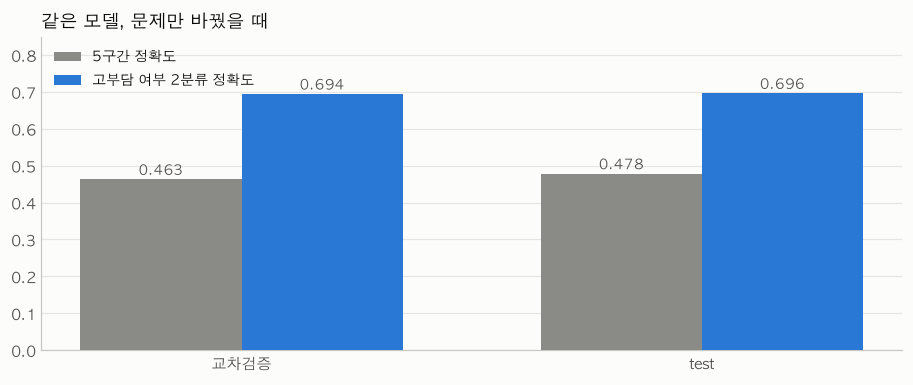

In [7]:
def binary(yy, pp, name):
    cm = confusion_matrix(yy<=2, pp<=2, labels=[True, False])
    tp, fn, fp, tn = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    display(pd.DataFrame(cm, index=['실제 고부담','실제 아님'], columns=['예측 고부담','예측 아님']))
    rec, pre, acc = tp/(tp+fn), tp/(tp+fp), (tp+tn)/len(yy)
    print(f'  재현율 {rec:.4f} · 정밀도 {pre:.4f} · 정확도 {acc:.4f}')
    print(f'  → 실제 고부담 10명 중 {rec*10:.1f}명을 잡아내고, 고부담이라 안내한 10명 중 {pre*10:.1f}명이 실제 고부담')
    return {'구분':name, '재현율':rec, '정밀도':pre, '정확도':acc,
            '5구간 정확도': (pp==yy).mean()}

print('══ 교차검증 ══');  a = binary(y,   pred_cv, '교차검증')
print('\n══ test ══');    b = binary(yte, pred_te, 'test')
cmp = pd.DataFrame([a,b]).set_index('구분')
display(cmp.round(4))

fig, ax = plt.subplots(figsize=(8.4, 3.6)); style(ax)
x = np.arange(2); w_ = 0.35
ax.bar(x-w_/2, cmp['5구간 정확도'], w_, color=CAT3, zorder=3, label='5구간 정확도')
ax.bar(x+w_/2, cmp['정확도'],       w_, color=CAT1, zorder=3, label='고부담 여부 2분류 정확도')
for i,(v1,v2) in enumerate(zip(cmp['5구간 정확도'], cmp['정확도'])):
    ax.annotate(f'{v1:.3f}', (i-w_/2, v1), ha='center', va='bottom', fontsize=9, color=INK2)
    ax.annotate(f'{v2:.3f}', (i+w_/2, v2), ha='center', va='bottom', fontsize=9, color=INK2)
ax.set_xticks(x); ax.set_xticklabels(cmp.index); ax.set_ylim(0, 0.85)
ax.set_title('같은 모델, 문제만 바꿨을 때', loc='left')
ax.legend(frameon=False, fontsize=9); fig.tight_layout(); plt.show()

## 8. 성공 기준 판정

In [8]:
from sklearn.metrics import f1_score

# SC-004·SC-005 는 "38변수 전체 모델 대비 손실" 로 정의된다. 그 기준 모델을 test 로 잰다.
enc38 = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(d['X'])
lr38 = LogisticRegression(max_iter=2000, random_state=T.SEED).fit(enc38.transform(d['X']), y)
p38 = T.decide(lr38.predict_proba(enc38.transform(d['Xtest'])), [1.2, 1.2, 1.0, 1.0, 1.0])
f1_38, rec_38 = f1_score(yte,p38,average='macro'), ((p38<=2)&(yte<=2)).sum()/(yte<=2).sum()
f1_7,  rec_7  = f1_score(yte,pred_te,average='macro'), ((pred_te<=2)&(yte<=2)).sum()/(yte<=2).sum()

unc = json.loads((ROOT/'models'/'uncertainty_v1.json').read_text(encoding='utf-8'))
checks = [
    ('SC-004  macro F1 손실 ≤ 0.03', f'{f1_38-f1_7:+.4f}  (7문항 {f1_7:.4f} / 38문항 {f1_38:.4f})', f1_38-f1_7 <= 0.03),
    ('SC-005  재현율 손실 ≤ 0.05',   f'{rec_38-rec_7:+.4f}  (7문항 {rec_7:.4f} / 38문항 {rec_38:.4f})', rec_38-rec_7 <= 0.05),
    ('SC-005  재현율 ≥ 0.70',        f'{rec_7:.4f}', rec_7 >= 0.70),
    ('SC-016  판정 불가 ≤ 10%',      f"{unc['rate']*100:.2f}% (train 기준)", unc['rate'] <= 0.10),
    ('SC-016  판정불가 오분류 > 판정', f"{unc['err_undecidable']:.3f} > {unc['err_decided']:.3f}",
                                      unc['err_undecidable'] > unc['err_decided']),
]
display(pd.DataFrame([{'기준':a, '실측':b, '판정':'PASS' if ok else 'FAIL'} for a,b,ok in checks]))

,기준,실측,판정
0,SC-004 macro F1 손실 ≤ 0.03,+0.0145 (7문항 0.3416 / 38문항 0.3561),PASS
1,SC-005 재현율 손실 ≤ 0.05,+0.0061 (7문항 0.7730 / 38문항 0.7791),PASS
2,SC-005 재현율 ≥ 0.70,0.7730,PASS
3,SC-016 판정 불가 ≤ 10%,3.00% (train 기준),PASS
4,SC-016 판정불가 오분류 > 판정,0.625 > 0.534,PASS


---

## 정리

| 무엇 | 값 |
|---|---|
| 5구간 정확도 (test) | **0.478** — 무작위 0.20, 최빈값 찍기 0.387 |
| **고부담 여부 정확도 (test)** | **0.696** |
| **고부담 재현율 (test)** | **0.773** — 실제 고부담 10명 중 7.7명을 잡는다 |
| 고부담 정밀도 (test) | 0.698 |
| 폴드 간 정확도 편차 | 0.044 — 안정적 |
| 성공 기준 | SC-004·SC-005·SC-016 전부 통과 |

## 왜 5구간 정확도가 낮은가

모델 탓이 아니다. y 를 빼고 군집화하면 실루엣 0.12, 부담 구간과의 일치도 ARI 0.027 이다 —
**설명변수가 돌봄부담을 5구간으로 가를 만큼의 정보를 담고 있지 않다.**
자세히는 `notebooks/HG-실험-군집화.ipynb`.

## 이 노트북이 하지 않은 것

- DB 에 쓰지 않았다 · `models/` 를 건드리지 않았다
- test 602건은 **평가에만** 썼다. 이 결과로 모델을 바꾸면 오염된다